In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn import linear_model

In [2]:
import_path = Path.cwd().parent
os.sys.path.insert(0, str(import_path))
import feature_utils as futils
import pca_utils as putils

save_path = r"C:\Users\Lindholm\Dropbox\BSc\report_figures\pca_reconstruction"

In [3]:
val1_path = r"D:\logmel_outputs_9979\Tracy_6230\6230.220917120000.npz"
s1 = np.load(val1_path)["feature"]
spec = s1[0]
sr = 64000
hop_length = 512
fps = sr / hop_length
mels_start = 9
mels_end = 60
seg_sec = 5.0
T_target = 300

print(f"Spec shape: {spec.shape}")
print(f"Shape = {spec[mels_start:mels_end, :].shape}")

Spec shape: (128, 33125)
Shape = (51, 33125)


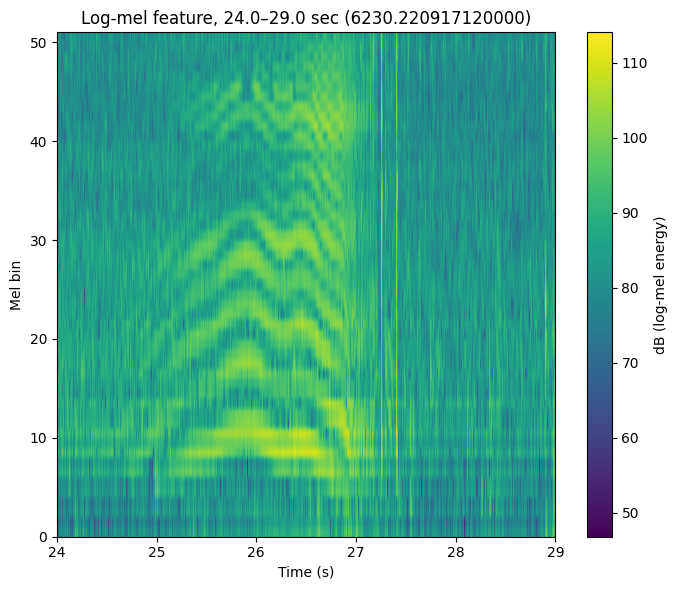

In [4]:
t_start, t_end = 24.0, 29.0
i_start = int(t_start * fps)
i_end   = int(t_end * fps)

seg1 = spec[mels_start:mels_end, i_start:i_end]

plt.figure(figsize=(7, 6))
im = plt.imshow(
    seg1,
    origin="lower",
    aspect="auto",
    extent=[t_start, t_end, 0, seg1.shape[0]]  # x-axis in seconds
)
plt.colorbar(im, label="dB (log-mel energy)")
plt.xlabel("Time (s)")
plt.ylabel("Mel bin")
plt.title(f"Log-mel feature, {t_start}–{t_end} sec (6230.220917120000)")
plt.tight_layout()
plt.show()

#### Compare with other spectrograms from clusters

## Test downsampling

In [5]:
print("Segment shape:", seg1.shape)
print("Flattened shape:", seg1.flatten().shape)
T_target = 300
seg1_ds = futils.downsample_time_avgpool_from_db(seg1, T_target=T_target, ref=1.0)
print("Downsampled shape:", seg1_ds.shape)
print("Flattened shape:", seg1_ds.flatten().shape)

Segment shape: (51, 625)
Flattened shape: (31875,)
Downsampled shape: torch.Size([51, 300])
Flattened shape: torch.Size([15300])


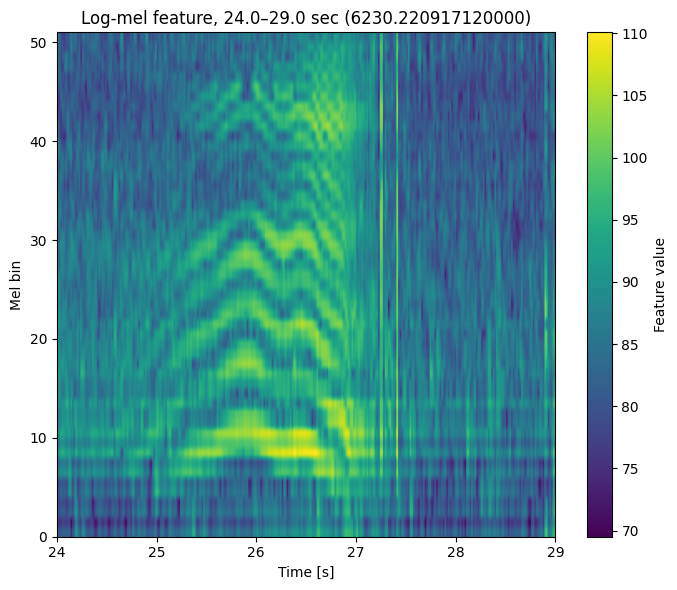

In [6]:
plt.figure(figsize=(7, 6))
im = plt.imshow(
    seg1_ds,
    origin="lower",
    aspect="auto",
    extent=[t_start, t_end, 0, seg1.shape[0]]  # x-axis in seconds
)
plt.colorbar(im, label="Feature value")
plt.xlabel("Time [s]")
plt.ylabel("Mel bin")
plt.title(f"Log-mel feature, {t_start}–{t_end} sec (6230.220917120000)")
plt.tight_layout()
plt.show()

## Spectrogram reconstruction

In [7]:
# Flatten the spectrogram segment.
x = seg1_ds
m, t = x.shape
x_flat = x.flatten()
# Reshape to 2D s = (t, m).
x2 = x.T
print(x2.shape)

torch.Size([300, 51])


In [8]:
n_comps = [2**i for i in range(1, 6)]
print("Max n_components:", max(n_comps))
recon_errors = []
for nc in n_comps:
    pca = PCA(n_components=nc)
    z = pca.fit_transform(x2)
    x_hat = pca.inverse_transform(z)

    error = np.linalg.norm(x2 - x_hat)
    recon_errors.append(error)

    print(nc, error)

Max n_components: 32
2 394.75606192946873
4 330.7837766470249
8 261.3084682023525
16 176.71674486176286
32 66.5055775071219


In [9]:
[2**i for i in range(1, 10)]

[2, 4, 8, 16, 32, 64, 128, 256, 512]

In [10]:
n_components = 2**4
pca = PCA(n_components=n_components)
z = pca.fit_transform(x2)
x_hat = pca.inverse_transform(z)
error = np.linalg.norm(x2 - x_hat)
print(f"Reconstruction error with {n_components} components:", error)
seg1_recon = x_hat.T

Reconstruction error with 16 components: 176.71674486176286


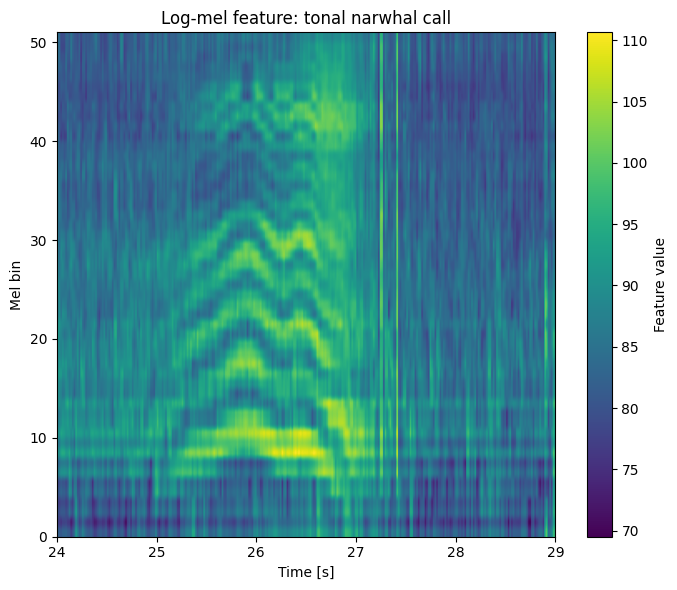

In [11]:
plt.figure(figsize=(7, 6))
im = plt.imshow(
    seg1_recon,
    origin="lower",
    aspect="auto",
    extent=[t_start, t_end, 0, seg1_recon.shape[0]]  # x-axis in seconds
)
plt.colorbar(im, label="Feature value")
plt.xlabel("Time [s]")
plt.ylabel("Mel bin")
plt.title("Log-mel feature: tonal narwhal call")
plt.tight_layout()
plt.show()

## Flattened

In [12]:
m_full, t_full = spec.shape
frames_per_seg = int(seg_sec * fps)
n_clips = int(t_full // frames_per_seg)

segs_list = []
for clip in range(n_clips):
    start = int(clip * frames_per_seg)
    end = int((clip + 1) * frames_per_seg)
    seg = spec[mels_start:mels_end, start:end]
    segs_list.append(seg)

segs = np.stack(segs_list, axis=0) # (n_segs, m, t).
n, m, t = segs.shape

X = segs.astype(np.float32).reshape(n, -1) # (n_segs, m*t).
D = X.shape[1]
print("X shape =", X.shape)
print("Flattened dimension", D)

X shape = (53, 31875)
Flattened dimension 31875


In [13]:
# Standardize features
# Computed from valid sample.
scaler_mean = X.mean(axis=0)
scaler_scale = X.std(axis=0, ddof=0)
scaler_scale[scaler_scale == 0] = 1.0
X_sc = (X - scaler_mean) / scaler_scale
# Computed from all observations.

In [14]:
max_comps = 64
max_comps = min(max_comps, X_sc.shape[0], X_sc.shape[1])

pca = PCA(n_components=max_comps)
Z = pca.fit_transform(X_sc)

ipca_comps = pca.components_  # (K, D).
ipca_mean = pca.mean_ # (D,).
explained_var_ratio = pca.explained_variance_ratio_
print("PCA components =", ipca_comps.shape)
print("Explained variance ratios:", explained_var_ratio[0:10])

PCA components = (53, 31875)
Explained variance ratios: [0.1191012  0.04922536 0.02985934 0.02561233 0.02459666 0.02261356
 0.02166578 0.02041853 0.01990028 0.01964262]


In [15]:
k_list = [2, 4, 8, 16, 32, 64]
errors = {}
seg1_recons = X[8:9, :].reshape(m, t)
for k in k_list:
    if k > ipca_comps.shape[0]:
        continue
    seg1_hat = putils.reconstruct_segment(seg1_recons, k, scaler_mean, scaler_scale, ipca_mean, ipca_comps)
    err = np.linalg.norm(seg1_recons - seg1_hat)  # Frobenius norm.
    errors[k] = err
    print(f"k={k:2d}, error={err:.3e}")

evr_cum = np.cumsum(explained_var_ratio)
for k in k_list:
    if k > len(evr_cum):
        continue
    print(f"k={k:2d}, EVR={evr_cum[k-1]:.4f}")


k= 2, error=9.293e+02
k= 4, error=9.292e+02
k= 8, error=9.184e+02
k=16, error=8.926e+02
k=32, error=4.865e+02
k= 2, EVR=0.1683
k= 4, EVR=0.2238
k= 8, EVR=0.3131
k=16, EVR=0.4627
k=32, EVR=0.7200


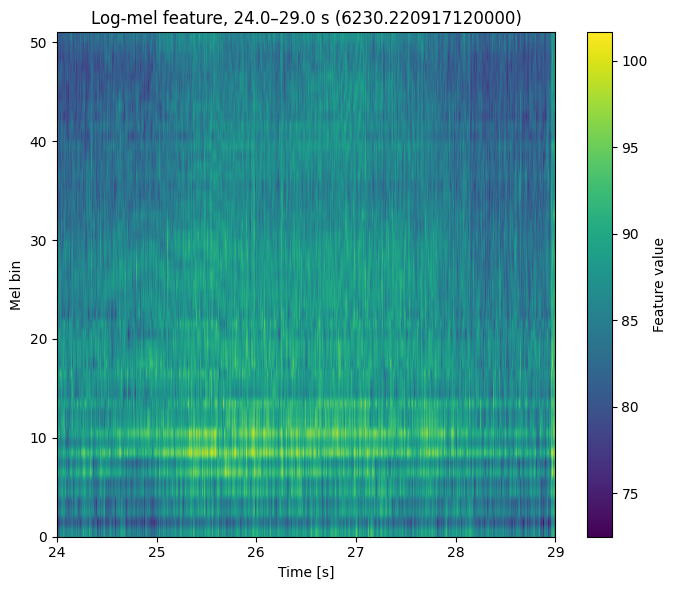

In [16]:
n_pcs = 2**5
seg1_hat = putils.reconstruct_segment(seg1, n_pcs, scaler_mean, scaler_scale, ipca_mean, ipca_comps)

plt.figure(figsize=(7, 6))
im = plt.imshow(
    seg1_hat,
    origin="lower",
    aspect="auto",
    extent=[t_start, t_end, 0, seg1_hat.shape[0]]  # x-axis in seconds
)
plt.colorbar(im, label="Feature value")
plt.xlabel("Time [s]")
plt.ylabel("Mel bin")
plt.title(f"Log-mel feature, {t_start}–{t_end} s (6230.220917120000)")
plt.tight_layout()
plt.show()

## Pseudo-global scaler

In [17]:
data_root = Path(r"D:\logmel_outputs_9979")
out_path = Path(r"D:\scaler_experiment")
narwhal_path = val1_path

In [18]:
# # n_samples = [i**2 for i in range(80, 750, 70)]
# n_samples = 10_000
# # for i in n_samples:
# # print(f"Computing pseudo-global scaler for {i} segments...")
# print(f"Computing pseudo-global scaler for {n_samples} segments...")
# scaler_mean_pg, scaler_scale_pg = compute_pseudo_global_scaler(
#     data_root,
#     target_segments=n_samples,
#     batch_segments=128,
#     segment_sec=seg_sec,
#     clip_sec=265.0,
#     mels_start=mels_start,
#     mels_end=mels_end,
#     key="feature",
#     seed=104,
#     downsample_T=T_target,
# )
# save_path = out_path / f"scaler_n_{n_samples}_shape_{scaler_mean_pg.shape}.npz"
# np.savez_compressed(save_path, n_segments=np.array(n_samples, dtype=np.int64)
#     , mean=scaler_mean_pg, scale=scaler_scale_pg)
# print(f"Saved {save_path}")

In [19]:
# # Pseudo-global scaler.
# scaler_mean = np.load(save_path)["mean"]
# scaler_scale = np.load(save_path)["scale"]
# print("Scaler mean shape:", scaler_mean.shape)
# print("Scaler mean =", scaler_mean.mean())
# print("Scaler scale =", scaler_scale.mean())

### Load scaler from full dataset PCA

In [20]:
# save_path = r"D:\segs_clust_5762\segments_ipca.npz"
save_path = r"E:\segs_clust_7079\segments_ipca.npz" # Underwater reference.
scaler_mean = np.load(save_path)["scaler_mean"]
scaler_scale = np.load(save_path)["scaler_scale"]

In [21]:
print("scaler mean = ", scaler_mean.mean())
print("scaler scale = ", scaler_scale.mean())

scaler mean =  82.360054
scaler scale =  13.402014


## PCA: testing reconstructions

In [22]:
n_samples = 1000 # N files.
max_train_segs = n_samples * 53 # N segments.
max_val_segs = 53
segment_sec = seg_sec
clip_sec = 265.0
key = "feature"
batch_segments = 128
expo = 13
K_max = 2**expo # Max number of PCA components.

In [23]:
print("Shape =", seg1.shape)
print("Shape =", seg1_ds.shape)
print([2**i for i in range(1, expo+1)])
print(2**expo) 

Shape = (51, 625)
Shape = torch.Size([51, 300])
[2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
8192


In [24]:
# all_files = putils.list_feature_files(data_root)
# rng = np.random.default_rng(104)
# # Randomly choose n files.
# train_files = rng.choice(all_files, size=n_samples, replace=False).tolist()
# if train_files.__contains__(Path(narwhal_path)):
#     print("Narwhal file was included in training files.")
# else:
#     train_files.append(Path(narwhal_path))

# max_train_segments = max_train_segs
# X_train, Z_train = putils.build_segment_matrix(
#     train_files,
#     scaler_mean,
#     scaler_scale,
#     max_segments=max_train_segments,
#     batch_segments=batch_segments,
#     segment_sec=segment_sec,
#     clip_sec=clip_sec,
#     mels_start=mels_start,
#     mels_end=mels_end,
#     key=key,
#     downsample_T=T_target,
# )

# print("Training matrix shape:", Z_train.shape)

# pca = PCA(n_components=K_max, svd_solver="randomized", random_state=0)
# pca.fit(Z_train)

# W = pca.components_.astype(np.float32) # (K_max, D).
# evr = pca.explained_variance_ratio_.astype(np.float32)

In [25]:
report_fig_path = r"C:\Users\Lindholm\Dropbox\BSc\report_figures" 
slurm_pca_path = Path(r"E:\segs_clust_7079")
with np.load(slurm_pca_path / "config_and_ipca.npz") as z:
    pop_evr = z["explained_variance_ratio"]

In [26]:
# cumu_evr = np.cumsum(evr)
# print("Cumulative explained variance:")
# print(cumu_evr[0:8])

# fig, ax = plt.subplots(figsize=(7, 5))
# k = 50
# ax.plot(np.arange(1, k+1), pop_evr[0:k].cumsum(), marker="o", markersize=5, color="royalblue", alpha=0.8, label="PCA(4096) on full data set.")
# ax.plot(np.arange(1, k+1), cumu_evr[0:k], marker="o", markersize=5, color="orange", alpha=0.5, label="PCA(8192) on experiment data set.")
# ax.set_xlabel("n components")
# ax.set_ylabel("Cumulative explained variance")
# ax.set_title("First components of PCA")
# ax.set_xlim(0, k)
# ax.set_ylim(0.90, 0.96)
# ax.grid()
# plt.legend()
# plt.tight_layout()
# plt.savefig(Path(report_fig_path) / "pca_exp_cumuvar.png", dpi=300)
# plt.show()

In [27]:
with np.load(slurm_pca_path / "config_and_ipca.npz") as z:
    ipca_components = z["ipca_components"]

X_val, Z_val = putils.build_segment_matrix([narwhal_path], scaler_mean, scaler_scale, max_segments=max_val_segs, clip_sec=clip_sec, downsample_T=T_target)

In [28]:
# Ks = [2**i for i in range(1, expo+1)]
Ks = [2**i for i in range(1, 13)]
recon_error = {}
for K in Ks:
    err, _ = putils.reconstruction_error_for_K(X_val, Z_val, ipca_components, scaler_mean, scaler_scale, K)
    recon_error[K] = err

print("Reconstruction errors on validation set:")
for i, K in enumerate(Ks):
    err = recon_error[K]
    print(f"K={2**(i+1):3d}, mean error={err.mean():.2e}, std={err.std():.2e}")

Reconstruction errors on validation set:
K=  2, mean error=1.88e+01, std=3.11e+01
K=  4, mean error=1.76e+01, std=3.10e+01
K=  8, mean error=1.67e+01, std=3.01e+01
K= 16, mean error=1.58e+01, std=2.81e+01
K= 32, mean error=1.47e+01, std=2.46e+01
K= 64, mean error=1.33e+01, std=1.83e+01
K=128, mean error=1.13e+01, std=1.02e+01
K=256, mean error=9.38e+00, std=4.19e+00
K=512, mean error=7.66e+00, std=2.04e+00
K=1024, mean error=5.84e+00, std=1.21e+00
K=2048, mean error=3.88e+00, std=5.14e-01
K=4096, mean error=2.02e+00, std=2.35e-01


In [29]:
y = np.array([recon_error[K].mean() for K in Ks])
x = np.log(np.array(Ks).reshape(-1, 1))
reg = linear_model.LinearRegression()
reg.fit(x, y)
print(reg.coef_)
print(reg.intercept_)
z = reg.predict(x)

[-2.23525384]
21.491253162875317


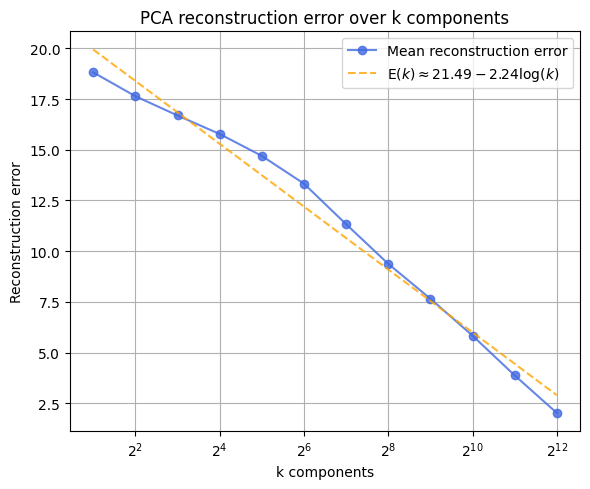

In [30]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(Ks, [recon_error[K].mean() for K in Ks], marker='o', color="royalblue", alpha=0.8, label="Mean reconstruction error")
ax.plot(Ks, z, color="orange", linestyle="--", alpha=0.8
    , label=f"E$(k)\\approx {reg.intercept_:.2f} {reg.coef_[0]:.2f} \log(k)$")
# ax.set_yscale('log', base=2)
ax.set_xscale('log', base=2)
plt.title("PCA reconstruction error over k components")
plt.xlabel("k components")
plt.ylabel("Reconstruction error")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

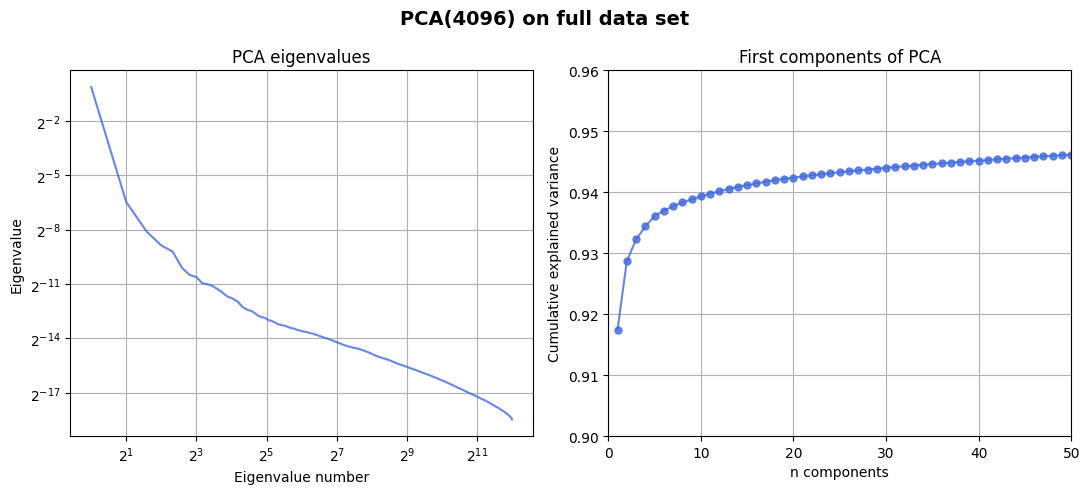

In [32]:
report_save_path = Path(r"C:\Users\Lindholm\Dropbox\BSc\report_figures\pca_reconstruction")
fig, ax = plt.subplots(1, 2, figsize=(11, 5))

eigvals = pop_evr
ax[0].plot(np.arange(1, len(eigvals)+1), eigvals, color="royalblue", alpha=0.8)
ax[0].set_yscale('log', base=2)
ax[0].set_xscale('log', base=2)
ax[0].set_ylabel("Eigenvalue")
ax[0].set_xlabel("Eigenvalue number")
ax[0].set_title("PCA eigenvalues")
ax[0].grid(True)

k = 50
ax[1].plot(np.arange(1, k+1), pop_evr[0:k].cumsum(), marker="o", markersize=5, color="royalblue", alpha=0.8)
ax[1].set_xlabel("n components")
ax[1].set_ylabel("Cumulative explained variance")
ax[1].set_title("First components of PCA")
ax[1].set_xlim(0, k)
ax[1].set_ylim(0.90, 0.96)
ax[1].grid()
fig.suptitle("PCA(4096) on full data set", fontweight="bold", fontsize=14)
# plt.legend()
plt.tight_layout()
plt.grid(True, axis="both")
plt.savefig(report_save_path / "eigenval_pca.png", dpi=300)
plt.show()

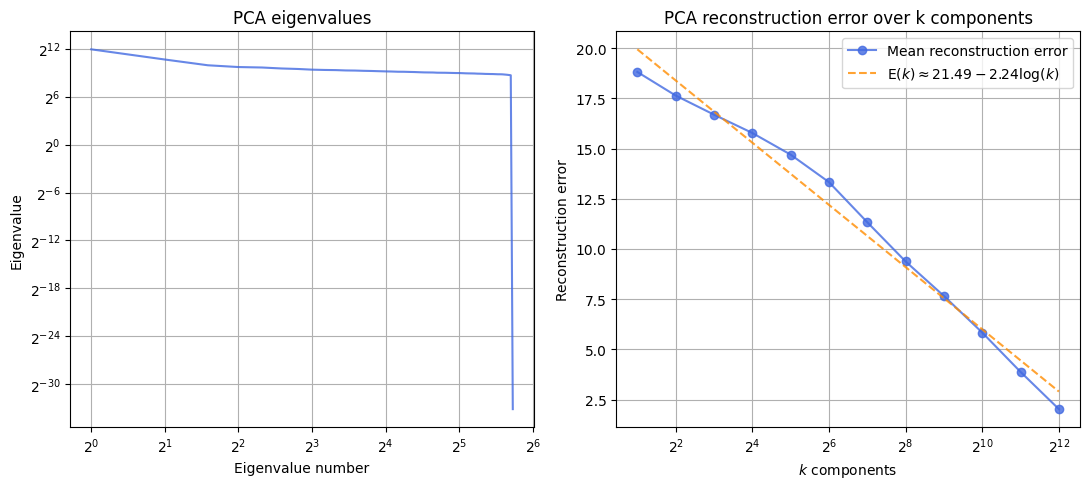

In [33]:
report_save_path = Path(r"C:\Users\Lindholm\Dropbox\BSc\report_figures\pca_reconstruction")
fig, ax = plt.subplots(1, 2, figsize=(11, 5))

eigvals = pca.explained_variance_.astype(np.float32)
ax[0].plot(np.arange(1, len(eigvals)+1), eigvals, color="royalblue", alpha=0.8)
ax[0].set_yscale('log', base=2)
ax[0].set_xscale('log', base=2)
ax[0].set_ylabel("Eigenvalue")
ax[0].set_xlabel("Eigenvalue number")
ax[0].set_title("PCA eigenvalues")
ax[0].grid(True)

ax[1].plot(Ks, [recon_error[K].mean() for K in Ks], marker='o', color="royalblue", alpha=0.8, label="Mean reconstruction error")
ax[1].plot(Ks, z, color="darkorange", linestyle="--", alpha=0.8
    , label=f"E$(k)\\approx {reg.intercept_:.2f} {reg.coef_[0]:.2f} \log(k)$")
# ax.set_yscale('log', base=2)
ax[1].set_xscale('log', base=2)
ax[1].set_title("PCA reconstruction error over k components")
ax[1].set_xlabel("$k$ components")
ax[1].set_ylabel("Reconstruction error")
ax[1].legend()
plt.tight_layout()
plt.grid(True, axis="both")
plt.savefig(report_save_path / "pca_eigen_recon_error.png", dpi=300)
plt.show()

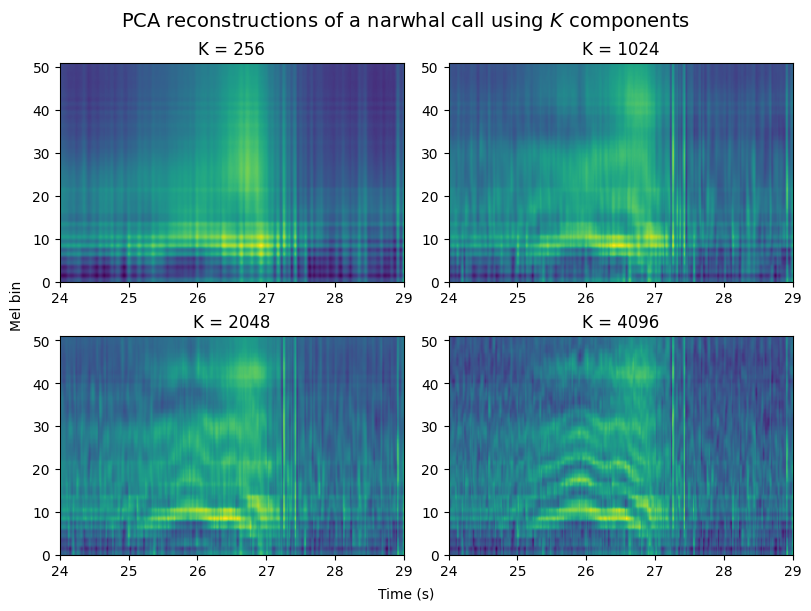

In [34]:
Ks = [2**i for i in [8, 10, 11, 12]]   # 16, 256, 4096

seg1_ds = futils.downsample_time_avgpool_from_db(seg1, T_target=T_target, ref=1.0).numpy()

fig, ax = plt.subplots(2, 2, figsize=(8, 6), constrained_layout=True)
axes = ax.ravel()

for j, K in enumerate(Ks, start=0):
    W_K = ipca_components[:K, :]  # (K, D)
    _seg_ds, seg_hat_ds = putils.reconstruct_from_segment_matrix(
        seg1, scaler_mean, scaler_scale, W_K, T_target=T_target
    )

    axes[j].imshow(
        seg_hat_ds, origin="lower", aspect="auto",
        extent=[t_start, t_end, 0, seg_hat_ds.shape[0]]
    )
    axes[j].set_title(f"K = {K}", fontsize=12)

# plt.colorbar(im, ax=axes.tolist(), label="dB")
plt.suptitle("PCA reconstructions of a narwhal call using $K$ components", fontsize=14)
fig.supxlabel("Time (s)", fontsize=10)
fig.supylabel("Mel bin", fontsize=10)  
plt.savefig(report_save_path / "pca_reconstructions.png", dpi=300)
plt.show()

In [35]:
j = 5
x2 = X_val[j][None, :]
z2 = Z_val[j][None, :]
Ks = [2**i for i in range(1, 13)]
recon_error = {}
for K in Ks:
    err, _ = putils.reconstruction_error_for_K(x2, z2, ipca_components, scaler_mean, scaler_scale, K)
    recon_error[K] = err

print("Reconstruction errors on validation set:")
for i, K in enumerate(Ks):
    err = recon_error[K]
    print(f"K={2**(i+1):3d}, mean error={err.mean():.2e}, std={err.std():.2e}")

Reconstruction errors on validation set:
K=  2, mean error=3.62e+01, std=0.00e+00
K=  4, mean error=2.81e+01, std=0.00e+00
K=  8, mean error=2.28e+01, std=0.00e+00
K= 16, mean error=1.98e+01, std=0.00e+00
K= 32, mean error=1.82e+01, std=0.00e+00
K= 64, mean error=1.76e+01, std=0.00e+00
K=128, mean error=1.62e+01, std=0.00e+00
K=256, mean error=1.42e+01, std=0.00e+00
K=512, mean error=1.22e+01, std=0.00e+00
K=1024, mean error=9.98e+00, std=0.00e+00
K=2048, mean error=6.65e+00, std=0.00e+00
K=4096, mean error=3.44e+00, std=0.00e+00


K* = 1024


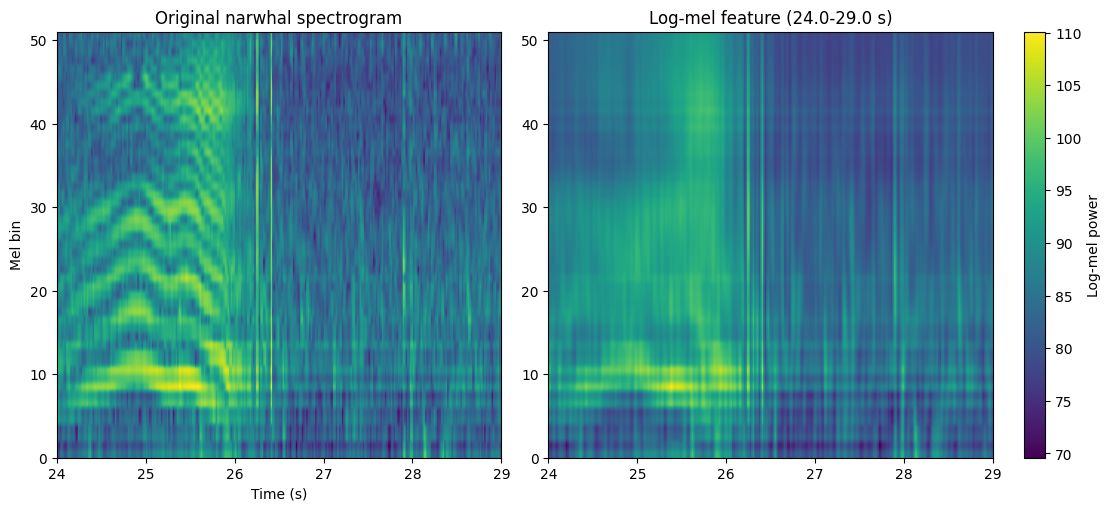

In [36]:
K_star = 2**10
print("K* =", K_star)
W_K = ipca_components[:K_star, :]  # (K_star, D).

seg2 = spec[mels_start:mels_end, int(j*seg_sec*fps):int((j+1)*seg_sec*fps)]
seg2_ds = futils.downsample_time_avgpool_from_db(seg2, T_target=T_target, ref=1.0)
seg2_ds, seg2_hat_ds = putils.reconstruct_from_segment_matrix(seg2, scaler_mean, scaler_scale
    , W_K, T_target=T_target,)

fig, ax = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
im1 = ax[0].imshow(
    seg2_ds,
    origin="lower",
    aspect="auto",
    extent=[t_start, t_end, 0, seg2.shape[0]]
)
im2 = ax[1].imshow(
    seg2_hat_ds,
    origin="lower",
    aspect="auto",
    extent=[t_start, t_end, 0, seg1.shape[0]]
)
plt.colorbar(im1, label="Log-mel power", ax=ax[1])
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Mel bin")
ax[0].set_title("Original narwhal spectrogram")
plt.title(f"Log-mel feature ({t_start}-{t_end} s)")
plt.show()

In [50]:
np.mean(np.mean((seg2_ds)**2, axis=1))

7268.9736

In [37]:
call_recon_error = recon_error

In [38]:
j = 6
x2 = X_val[j][None, :]
z2 = Z_val[j][None, :]
Ks = [2**i for i in range(1, 13)]
recon_error = {}
for K in Ks:
    err, _ = putils.reconstruction_error_for_K(x2, z2, ipca_components, scaler_mean, scaler_scale, K)
    recon_error[K] = err

print("Reconstruction errors on validation set:")
for i, K in enumerate(Ks):
    err = recon_error[K]
    print(f"K={2**(i+1):3d}, mean error={err.mean():.2e}, std={err.std():.2e}")

Reconstruction errors on validation set:
K=  2, mean error=1.30e+01, std=0.00e+00
K=  4, mean error=1.27e+01, std=0.00e+00
K=  8, mean error=1.23e+01, std=0.00e+00
K= 16, mean error=1.16e+01, std=0.00e+00
K= 32, mean error=1.11e+01, std=0.00e+00
K= 64, mean error=1.07e+01, std=0.00e+00
K=128, mean error=9.94e+00, std=0.00e+00
K=256, mean error=8.87e+00, std=0.00e+00
K=512, mean error=7.04e+00, std=0.00e+00
K=1024, mean error=5.57e+00, std=0.00e+00
K=2048, mean error=3.80e+00, std=0.00e+00
K=4096, mean error=1.92e+00, std=0.00e+00


K* = 1024


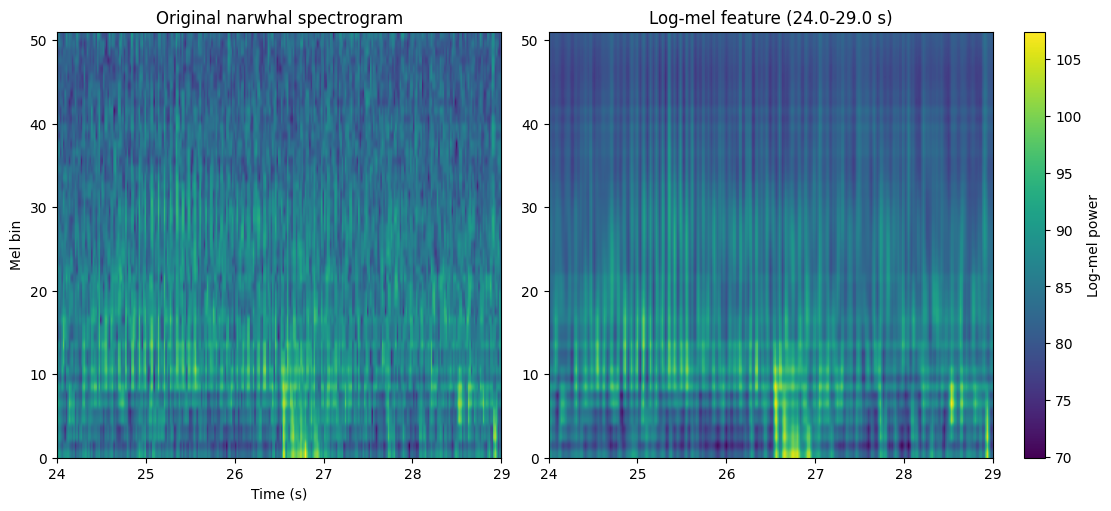

In [39]:
K_star = 2**10
print("K* =", K_star)
W_K = ipca_components[:K_star, :]  # (K_star, D).

seg2 = spec[mels_start:mels_end, int(j*seg_sec*fps):int((j+1)*seg_sec*fps)]
seg2_ds = futils.downsample_time_avgpool_from_db(seg2, T_target=T_target, ref=1.0)
seg2_ds, seg2_hat_ds = putils.reconstruct_from_segment_matrix(seg2, scaler_mean, scaler_scale
    , W_K, T_target=T_target,)

fig, ax = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
im1 = ax[0].imshow(
    seg2_ds,
    origin="lower",
    aspect="auto",
    extent=[t_start, t_end, 0, seg2.shape[0]]
)
im2 = ax[1].imshow(
    seg2_hat_ds,
    origin="lower",
    aspect="auto",
    extent=[t_start, t_end, 0, seg1.shape[0]]
)
plt.colorbar(im1, label="Log-mel power", ax=ax[1])
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Mel bin")
ax[0].set_title("Original narwhal spectrogram")
plt.title(f"Log-mel feature ({t_start}-{t_end} s)")
plt.show()

In [40]:
noise_recon_error = recon_error
noise_recon_error

{2: array([13.004057], dtype=float32),
 4: array([12.684663], dtype=float32),
 8: array([12.283719], dtype=float32),
 16: array([11.561049], dtype=float32),
 32: array([11.09454], dtype=float32),
 64: array([10.746143], dtype=float32),
 128: array([9.942605], dtype=float32),
 256: array([8.867412], dtype=float32),
 512: array([7.036986], dtype=float32),
 1024: array([5.5683904], dtype=float32),
 2048: array([3.800609], dtype=float32),
 4096: array([1.9153972], dtype=float32)}

In [41]:
Ks = [2**i for i in range(1, 13)]
y = np.array([call_recon_error[K].mean() for K in Ks])
x = np.log(np.array(Ks).reshape(-1, 1))
reg = linear_model.LinearRegression()
reg.fit(x, y)
print(reg.coef_)
print(reg.intercept_)
z = reg.predict(x)

[-3.50260059]
32.89068729227239


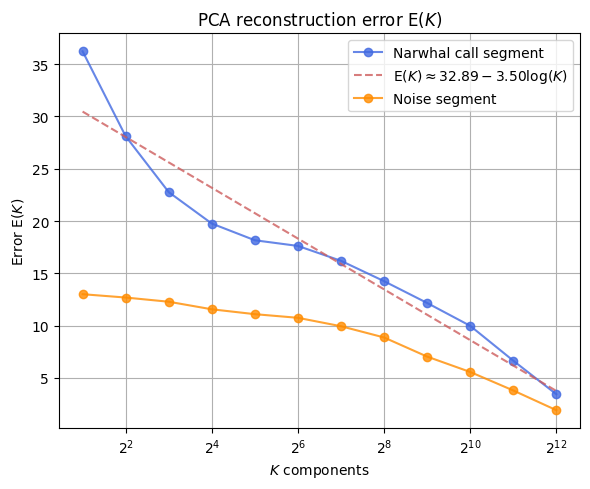

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.plot(Ks, [call_recon_error[K].mean() for K in Ks], marker='o', color="royalblue", alpha=0.8, label="Narwhal call segment")
ax.plot(Ks, z, color="indianred", linestyle="--", alpha=0.8, label=f"E$(K)\\approx {reg.intercept_:.2f} {reg.coef_[0]:.2f} \log(K)$")
ax.plot(Ks, [noise_recon_error[K].mean() for K in Ks], marker='o', color="darkorange", alpha=0.8, label="Noise segment")
ax.set_xscale('log', base=2)
plt.title("PCA reconstruction error E$(K)$")
plt.xlabel("$K$ components")
plt.ylabel("Error E$(K)$")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig(report_save_path / "pca_recon_error_call_vs_noise.png", dpi=300)
plt.show()